# Content and Objective

+ Show effects of lineare phase property

# Importing and Plotting Options

In [1]:
# importing
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

# showing figures inline
%matplotlib inline

In [2]:
# plotting options 
font = {'size'   : 20}
plt.rc('font', **font)
plt.rc('text', usetex=True)

matplotlib.rc('figure', figsize=(18, 10) )

# Function Providing RRC Shape

In [3]:
########################
# find impulse response of an RRC filter
########################
def get_rrc_ir(K, n_up, t_symb, r):
        
    ''' 
    Determines coefficients of an RRC filter 
    
    Formula out of: J. Huber, Trelliscodierung, Springer, 1992, S. 15
    At poles, values of wikipedia.de were used (without cross-checking)
    
    NOTE: Length of the IR has to be an odd number
    
    IN: length of IR, upsampling factor, symbol time, roll-off factor
    OUT: filter ceofficients
    '''

    assert K % 2 != 0, "Filter length needs to be odd"
    
    if r == 0:
        r = 1e-32

    # init
    rrc = np.zeros(K)
    t_sample = t_symb/n_up
    
        
    i_steps = np.arange( 0, K)
    k_steps = np.arange( -(K-1)/2.0, (K-1)/2.0 + 1 )    
    t_steps = k_steps*t_sample

    for i in i_steps:

        if t_steps[i] == 0:
            rrc[i] = 1.0/np.sqrt(t_symb) * (1.0 - r + 4.0 * r / np.pi )

        elif np.abs( t_steps[i] ) == t_symb/4.0/r:
            rrc[i] = r/np.sqrt(2.0*t_symb)*((1+2/np.pi)*np.sin(np.pi/4.0/r)+ \
                            ( 1.0 - 2.0/np.pi ) * np.cos(np.pi/4.0/r) )

        else:
            rrc[i] = 1.0/np.sqrt(t_symb)*( np.sin( np.pi*t_steps[i]/t_symb*(1-r) ) + \
                            4.0*r*t_steps[i]/t_symb * np.cos( np.pi*t_steps[i]/t_symb*(1+r) ) ) \
                            / (np.pi*t_steps[i]/t_symb*(1.0-(4.0*r*t_steps[i]/t_symb)**2.0))
 
    return rrc

# Simulating Effects

In [4]:
# parameters for rrc
t_symb = 1.0
beta = 0.33

# oversampling factor; samples per symbol
n_up = 4          

# symbols per filter (plus minus in both directions)
syms_per_filt = 4  

# length of the fir filter
K_filt = 2*syms_per_filt*n_up+1         

# get rrc impulse response
rrc = get_rrc_ir(n_up*syms_per_filt*2+1, n_up, t_symb, beta)
rrc /= np.linalg.norm( rrc )

In [5]:
# define length of impulse response
N_ir = 31

# ir adhering to the "linear phase requirement"
h_linphase = np.zeros( N_ir )
h_linphase[ : N_ir // 2 + 1 ] = np.random.rand( N_ir // 2 + 1)
h_linphase[ N_ir // 2 + 1 : ] = h_linphase[ : N_ir // 2 ][::-1] 

h_linphase = np.ones( N_ir )

h_linphase /= np.linalg.norm( h_linphase )

h_linphase = rrc

h_linphase_extended = np.hstack( [ h_linphase, np.zeros( 9*len(h_linphase ) ) ] )
H_linphase = np.fft.fft( h_linphase_extended )

delta_f = 1 / ( t_symb / n_up ) / len( h_linphase_extended )
f = np.arange( -1 / ( 2 * t_symb / n_up ), 1 / ( 2 * t_symb / n_up ) , delta_f ) 

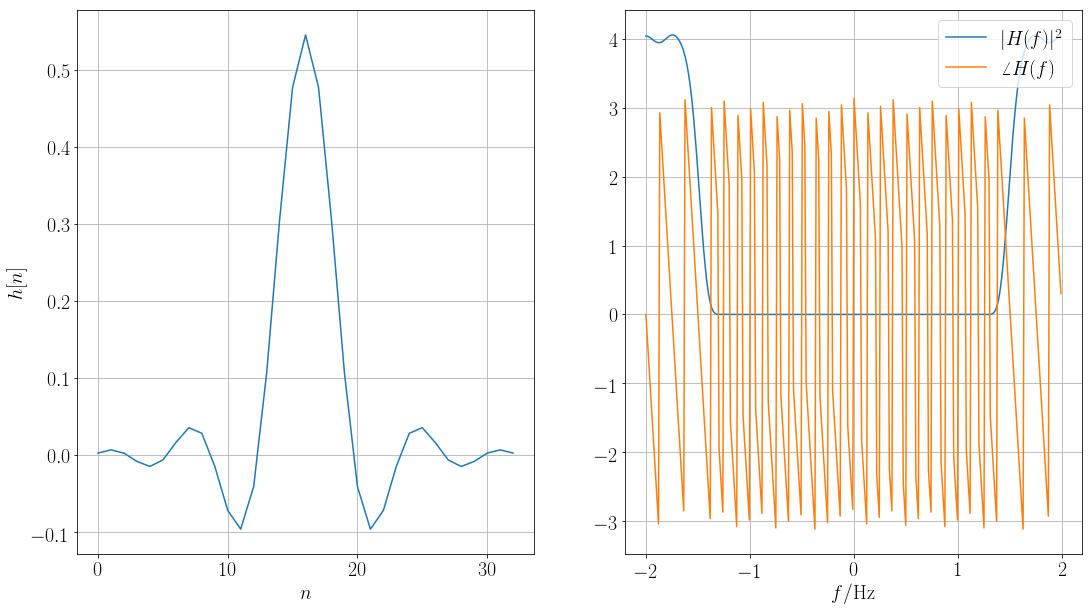

In [6]:
plt.figure()

plt.subplot(121)
plt.plot(h_linphase)

plt.grid( True )
plt.xlabel('$n$')
plt.ylabel('$h[n]$')

plt.subplot(122)


plt.plot( f, np.abs( np.fft.fft( h_linphase_extended))**2, label='$| H(f)|^2$')
plt.plot( f, np.angle( np.fft.fft( h_linphase_extended)), label='$\\angle H(f)$')

plt.grid( True )
plt.xlabel('$f / \\mathrm{Hz}$')
plt.legend( loc='upper right')

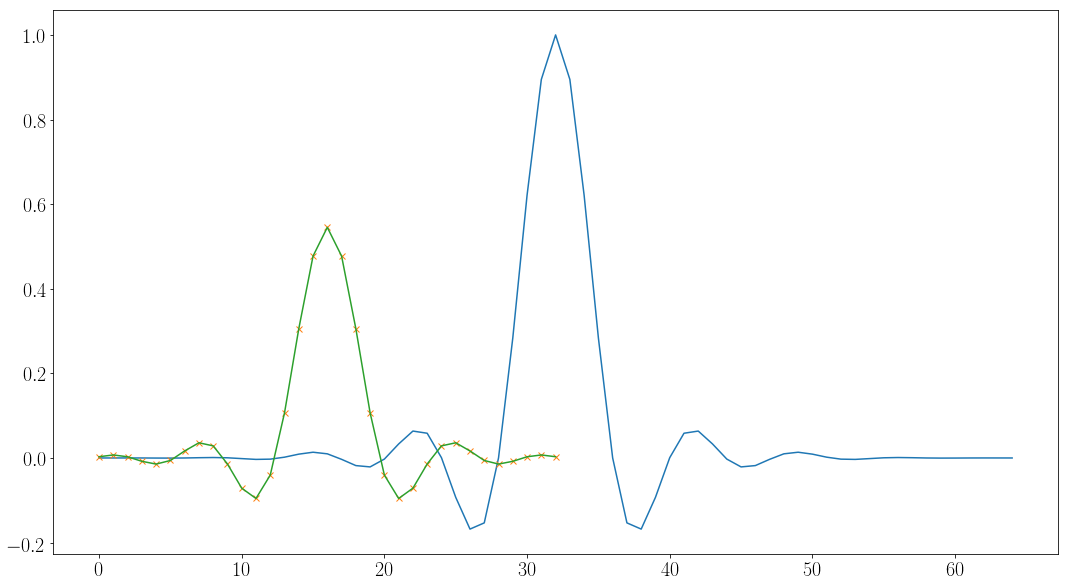

In [8]:
# now showing effects of filtering
y = np.convolve( rrc, h_linphase )

plt.figure()
plt.plot( y )
plt.plot( h_linphase,'x' )
plt.plot(rrc)